# Arbol de Desición y Bosque Aleatorio

Angélica Mata Zamora

## Parte 1: Arbol de Desición (Desition Tree)

In [12]:
import pandas as pd 
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

In [13]:
mydata = load_iris()

x = mydata.data # data de entrada 

y = mydata.target # data de salida

print(x.shape)
print(y.shape)

(150, 4)
(150,)


In [14]:
mydata.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [15]:
mydata.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [16]:
X_tv, x_test, y_tv, y_test = train_test_split(x, y, test_size=.2, shuffle=True, random_state=1)

x_train, x_val, y_train, y_val = train_test_split(x_tv, y_tv, test_size=.25, shuffle=True, random_state=1)

 

print('Tamaño del conjunto de entrenamiento:', x_train.shape)

print('Tamaño del conjunto de validación:', x_val.shape)

print('Tamaño del conjunto de prueba', x_test.shape)

Tamaño del conjunto de entrenamiento: (90, 4)
Tamaño del conjunto de validación: (30, 4)
Tamaño del conjunto de prueba (30, 4)


{'whiskers': [<matplotlib.lines.Line2D at 0x3133dbcb0>,
 'caps': [<matplotlib.lines.Line2D at 0x313494050>,
 'boxes': [<matplotlib.lines.Line2D at 0x3133dbb60>,
 'medians': [<matplotlib.lines.Line2D at 0x3134942f0>,
 'fliers': [<matplotlib.lines.Line2D at 0x313494440>,
 'means': []}

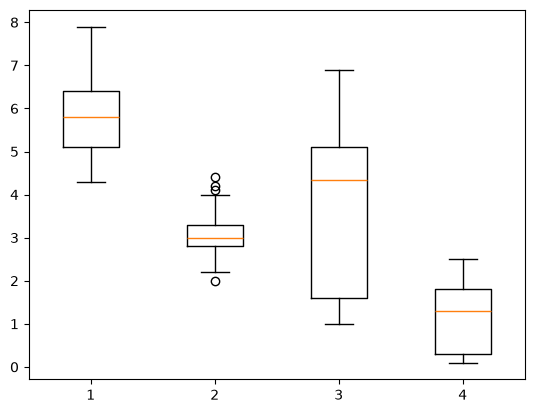

In [17]:
plt.boxplot(x, label=mydata.feature_names)

In [18]:
# Generemos un árbol de decisión

modelDT = DecisionTreeClassifier() # Iniciamos con los hiperparametros predeterminados

clf = modelDT.fit(x_train, y_train) # Entrenamos el modelo con datos de entrenamiento

#Observamos el desempeño
print('Exactitud en el conjunto de entrenamiento', clf.score(x_train,y_train))

Exactitud en el conjunto de entrenamiento 1.0


In [19]:
predicciones = clf.predict(x_val)
print ('Exactituf del conjunto de validación',clf.score(x_val,y_val))

Exactituf del conjunto de validación 0.9666666666666667


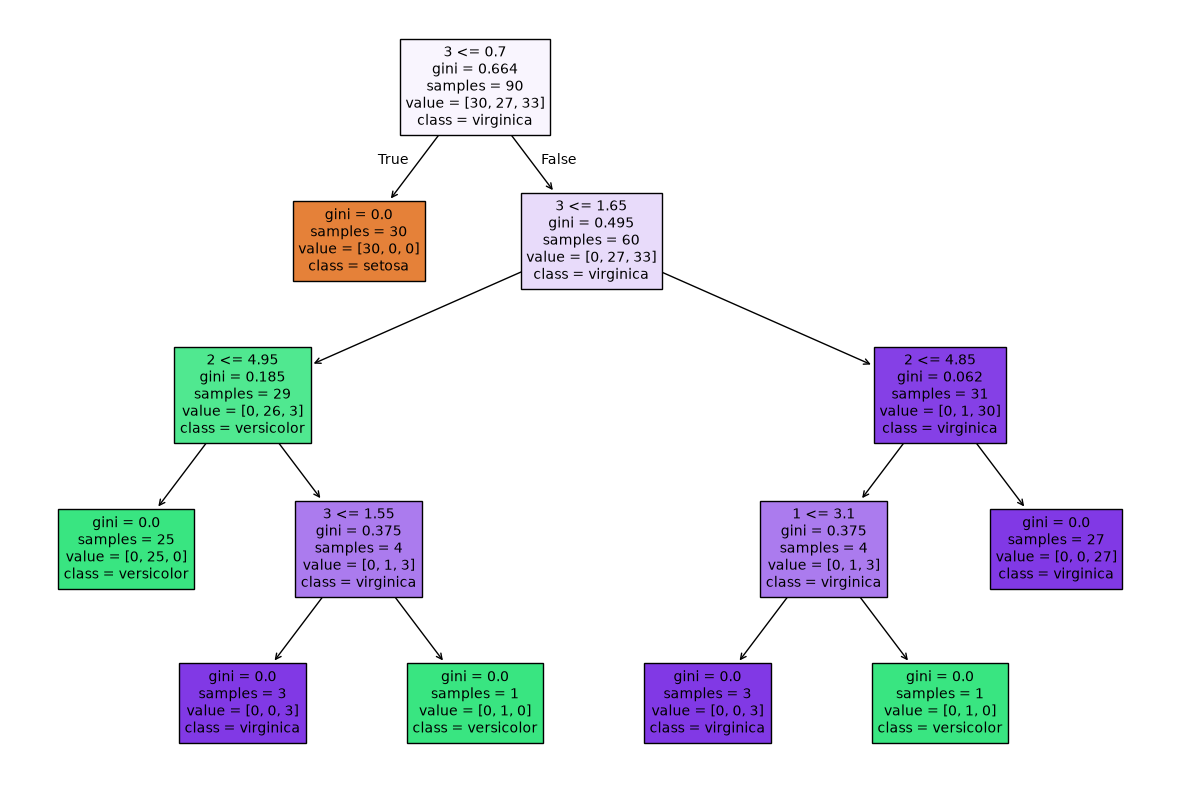

In [20]:
# Para realizar un grafo de Decision Tree
from sklearn import tree
# 1. Configurar el tamaño de la imagen
plt.figure(figsize=(15, 10))
# 2. Dibujar el árbol directamente
tree.plot_tree(decision_tree=clf,
               max_depth=None,
               feature_names=list(pd.DataFrame(x_train).columns.astype(str)),
               class_names=[str(c) for c in mydata.target_names],
               filled=True,
               proportion=False,
               fontsize=10)
# 3. Mostrar la imagen en Jupyter
plt.show()



## Paarte 2 -  Randome Forest (Bosque Aleatorio)

In [23]:
from sklearn.ensemble import RandomForestClassifier


In [24]:
import sklearn.datasets

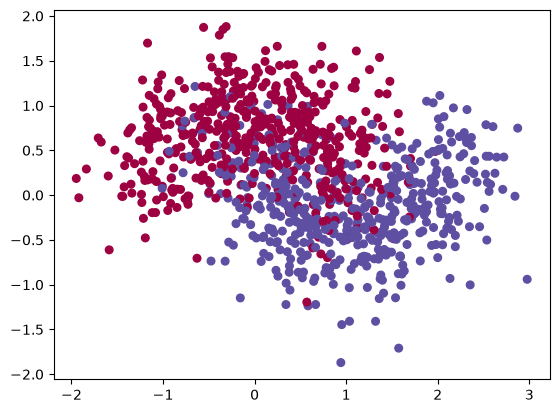

In [28]:
N=1000 #Total de Datos
noisy_data = sklearn.datasets.make_moons(n_samples=N, noise=0.4, random_state=17) #Genera datos con ruido
x,y = noisy_data

plt.scatter(x[:,0], x[:,1], c=y, s=30, cmap=plt.cm.Spectral)

In [36]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=.4, shuffle=True, random_state=17)

 

mimodelo = RandomForestClassifier()

 

clf = mimodelo.fit(xtrain,ytrain)

 

results = clf.predict(xtest)

 

confusion_matrix(ytest, results)

array([[166,  36],
       [ 30, 168]])

In [38]:
clf.score(xtest,ytest)

0.835

In [39]:
clf.feature_importances_

array([0.45352853, 0.54647147])

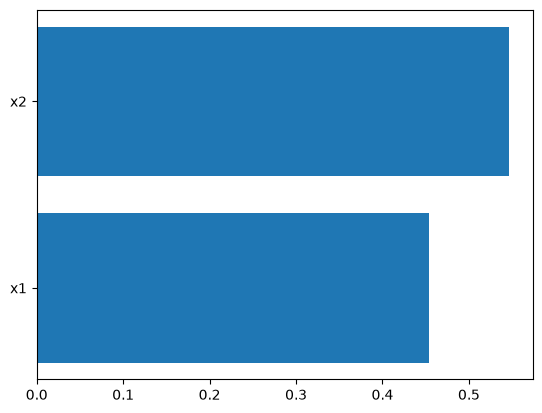

In [44]:
plt.barh(['x1','x2'], width=clf.feature_importances_);

In [45]:
## Algunos de lo hiperparámetros del clasificador bosque aleatorio:

mimodelo2 = RandomForestClassifier(n_estimators=10,  # número de árboles en el Forest y después promedia por votación.

                                   criterion='gini',   # métrica para determinar las ramas. También puede ser: 'entropy', para la GananciaDeInformación (IG).

                                   max_depth=2, # Depth=k : máximo 2^k líneas/ramas.        

                                   min_samples_split = 6,  # mínimo de puntos muestrales requeridos en un nodo para hacer la ramificación. Puede ser fracción de 0 a 1.

                                   min_samples_leaf = 4,  # mínimo de puntos muestrales que deben quedar en cada nueva ramificación (hojas). Puede ser fracción de 0 a 1.

                                   #max_features= 'auto',   # número de características (features) que se consideran en cada ramificación: auto=sqrt(n_features).

                                   max_leaf_nodes=16,  # solo nos quedamos con las mejores k hojas.

                                   bootstrap=True,  # Cada Árbol se muestrea seleccionando la cantidad de datos del conjunto de entrenamiento, pero con reemplazo. False:los datos usados en cada árbol simpre es el mismo, el Train-set.

                                   oob_score=True,  # en caso de utilizar Out-of-bag samples.

                                   verbose=0,     # tipo de despliega de información durante el entrenamiento.

                                   n_jobs=-1,    # total de hilos a usar en las rutinas paralelizables: "-1" :usar todos los posibles. 

                                   max_samples=None,   # Cuando se usa Boostrap, es el total de datos de Xtrain a usar en cada árbol. "None" usará Xtrain[0]. 

                                   random_state=19)

In [47]:
clf2 = mimodelo2.fit(xtrain,ytrain)

clf2.score(xtest,ytest)

/opt/anaconda3/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


0.855